# Part 1 - Initial IMDB Data Processing
- James M. Irving

## Business Problem

<img src="Images/movies-generic-header.png" width=300px>

> I have been hired to produce analyze IMDB's extensive publicly-available dataset, supplement it with financial data from TMDB's API, convert the raw data into a MySQL database, and then use that database for extracting insights and recommendations on how to make a successful movie.

I will use a combination of machine-learning-model-based insights and hypothesis testing to extract insights for our stakeholder.
    

  
### Specifications/Constraints    
- The stakeholder wants to focus on attributes of the movies themselves, vs the actors and directors connected to those movies. 
- They only want to include information related to movies released in the United States.
- They also did not want to include movies released before the year 2000.
- The stakeholder is particularly interested in how the MPAA rating, genre(s), runtime, budget, and production companies influence movie revenue and user-ratings.

# Initial IMDB Data Processing + More Data

### IMDB Movie Metadata
- I will download fresh movie metadata from IMDB's public datasets and filter out movies that meet the stakeholder's requirements/constraints.

- IMDB Provides Several Files with varied information for Movies, TV Shows, Made for TV Movies, etc.
    - Overview/Data Dictionary: <a href="https://www.imdb.com/interfaces/" target="_blank">https://www.imdb.com/interfaces/</a>

    - Downloads page: <a href="https://datasets.imdbws.com/" target="_blank">https://datasets.imdbws.com/</a>
- Files to use (previous):
    - title.basics.tsv.gz
    - title.ratings.tsv.gz
    - title.akas.tsv.gz
- Additional Files to Use:
    - title.crew.tsv.gz
    - title.principals.tsv.gz
    - name.basics.tsv.gz
  

## Imports and Downloading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import missingno

In [2]:
## Importing custom function for project
%load_ext autoreload
%autoreload 2
import project_functions as pf

In [3]:
## Making "Data" Folder to save IMDB files
os.makedirs("Data/",exist_ok=True)
sorted(os.listdir("Data/"))

['combined_tmdb_api_data.csv.gz',
 'final_tmdb_data_2000.csv.gz',
 'final_tmdb_data_2001.csv.gz',
 'final_tmdb_data_2002.csv.gz',
 'final_tmdb_data_2003.csv.gz',
 'final_tmdb_data_2004.csv.gz',
 'final_tmdb_data_2005.csv.gz',
 'final_tmdb_data_2006.csv.gz',
 'final_tmdb_data_2007.csv.gz',
 'final_tmdb_data_2008.csv.gz',
 'final_tmdb_data_2009.csv.gz',
 'final_tmdb_data_2010.csv.gz',
 'final_tmdb_data_2011.csv.gz',
 'final_tmdb_data_2012.csv.gz',
 'final_tmdb_data_2013.csv.gz',
 'final_tmdb_data_2014.csv.gz',
 'final_tmdb_data_2015.csv.gz',
 'final_tmdb_data_2016.csv.gz',
 'final_tmdb_data_2017.csv.gz',
 'final_tmdb_data_2018.csv.gz',
 'final_tmdb_data_2019.csv.gz',
 'final_tmdb_data_2020.csv.gz',
 'final_tmdb_data_2021.csv.gz',
 'final_tmdb_data_2022.csv.gz',
 'title_akas_cleaned.csv.gz',
 'title_basics_cleaned.csv.gz',
 'title_ratings_cleaned.csv.gz',
 'tmdb_api_results_2000.json']

## Processing Title Basics

In [4]:
## title basics 
url_title_basics = 'https://datasets.imdbws.com/title.basics.tsv.gz'
basics = pd.read_csv(url_title_basics, sep='\t',low_memory=False)
basics.info()
basics.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8947945 entries, 0 to 8947944
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 614.4+ MB


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"


### Specified Filtering/Cleaning Steps:
- Permanent Steps
    - Replace "\N" with np.nan
    - keep only titleType==Movie
    - keep startYear 2000-2022
    
- Steps to Revisit/Reconsider:
    - Eliminate movies that include  "Documentary" in genre (see tip below)
    - Eliminate movies that are null for runtimeMinutes
    - Eliminate movies that are null for genre


In [5]:
# pf.check_nulls_nunique()
# def check_nulls_nunique(df,plot=True):
#     report = pd.DataFrame({"# null":df.isna().sum(),
#                  "% null":df.isna().sum()/len(df)*100,
#                  '# unique':df.nunique(),
#                           '% unique':df.nunique()/len(df)*100})
#     display(report.round(2))
#     if plot:
#         missingno.matrix(df)
#         plt.show()
    

#### Check for Nulls Values & \N placeholders

,# null,% null,# unique,% unique
tconst,0,0.0,8947945,100.00
titleType,0,0.0,11,0.00
primaryTitle,11,0.0,4126226,46.11
originalTitle,11,0.0,4146185,46.34
isAdult,0,0.0,9,0.00
startYear,0,0.0,151,0.00
endYear,0,0.0,98,0.00
runtimeMinutes,0,0.0,870,0.01
genres,10,0.0,2314,0.03


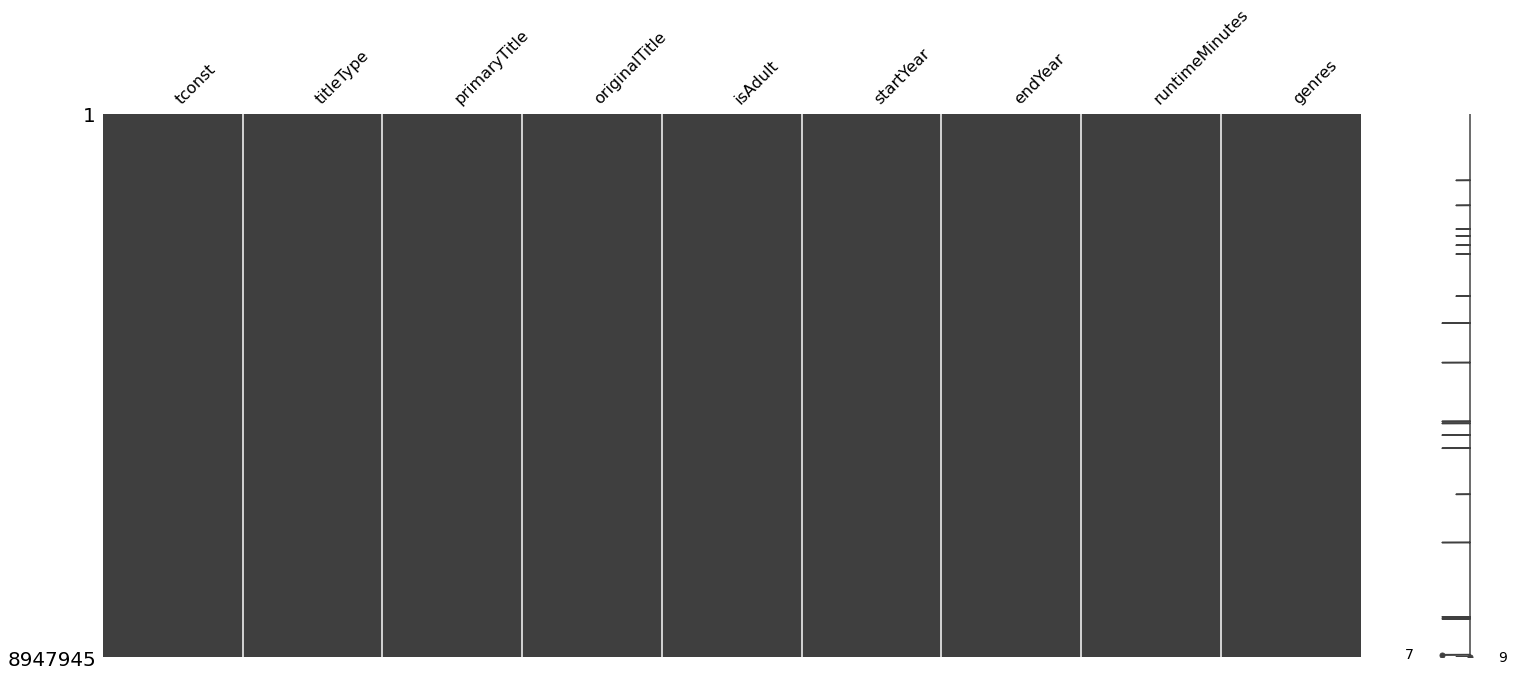

In [6]:
## checking null values
pf.check_nulls_nunique(basics)

,# null,% null,# unique,% unique
tconst,0,0.00,8947945,100.00
titleType,0,0.00,11,0.00
primaryTitle,11,0.00,4126226,46.11
originalTitle,11,0.00,4146185,46.34
isAdult,1,0.00,8,0.00
startYear,1192423,13.33,150,0.00
endYear,8856955,98.98,97,0.00
runtimeMinutes,6541214,73.10,869,0.01
genres,408575,4.57,2313,0.03


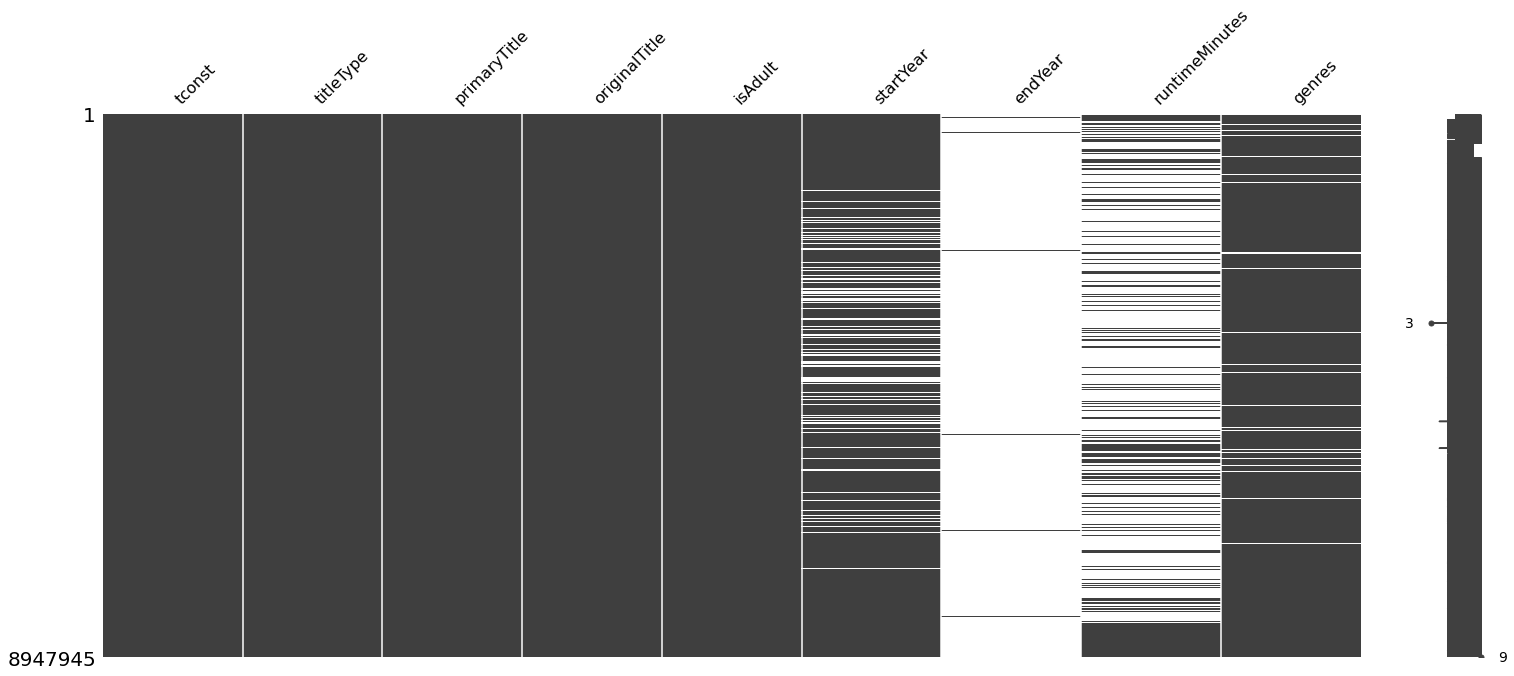

In [7]:
## Replace "\N" with np.nan
basics.replace({'\\N':np.nan},inplace=True)
pf.check_nulls_nunique(basics)

##### Observations:
- Note: `endYear` is a pretty worthless column, in relation to movies. For TV shows, this would have potentially been worth keeping. 
    - Decision: Drop column.
- `tconst` vs `primary_title`:
    - I find it somehow odd that there are unique tconst values for every row, but that only ~ 46% of the titles are unique values.
        - Decision: change nothing, for now, but remember this for later.
        
- `genres` are missing for <5% of the movies.
    - Decision: we care about genre, so we will drop null values from genre.

- `startYear` is missing for 13% of the data. This may reflect movies that yet to be released.
    - Decision: drop null values for now. Alternative future approach would be to confirm movie status by joining with other table containing release information.
    
- `runtimeMinutes` is missing from a whopping 73% of the data. 
    - Decision: since this is a feature we care about, it is vital to our analysis. We will drop null values from this feature to reduce the overall number of API calls needed in Part 2.

In [8]:
## Eliminate movies that are null for runtimeMinute, genres, and startYear
basics = basics.dropna(subset=['runtimeMinutes','genres','startYear'])
pf.check_nulls_nunique(basics, plot=False)

,# null,% null,# unique,% unique
tconst,0,0.00,2305621,100.00
titleType,0,0.00,10,0.00
primaryTitle,0,0.00,1649280,71.53
originalTitle,0,0.00,1666426,72.28
isAdult,0,0.00,2,0.00
startYear,0,0.00,147,0.01
endYear,2262364,98.12,95,0.00
runtimeMinutes,0,0.00,848,0.04
genres,0,0.00,2187,0.09


In [9]:
## drop endYear
basics = basics.drop(columns=['endYear'])
basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,1,"Comedy,Short"
...,...,...,...,...,...,...,...,...
8947895,tt9916754,movie,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,0,2013,49,Documentary
8947901,tt9916766,tvEpisode,Episode #10.15,Episode #10.15,0,2019,43,"Family,Game-Show,Reality-TV"
8947936,tt9916840,tvEpisode,Horrid Henry's Comic Caper,Horrid Henry's Comic Caper,0,2014,11,"Adventure,Animation,Comedy"
8947943,tt9916856,short,The Wind,The Wind,0,2015,27,Short


### Filtering for Stakeholder Specifications

#### Keeping only Full-Length Movies Released in Theaters

In [10]:
## Checking title types
basics['titleType'].value_counts()

tvEpisode       1005547
short            559636
movie            355401
video            172291
tvMovie           87235
tvSeries          84513
tvSpecial         15999
tvMiniSeries      15505
tvShort            9203
videoGame           291
Name: titleType, dtype: int64

In [11]:
## keep only titleType==Movie
basics = basics.loc[ basics['titleType']=='movie']
basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
570,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70,"Action,Adventure,Biography"
587,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,90,Drama
672,tt0000679,movie,The Fairylogue and Radio-Plays,The Fairylogue and Radio-Plays,0,1908,120,"Adventure,Fantasy"
1172,tt0001184,movie,Don Juan de Serrallonga,Don Juan de Serrallonga,0,1910,58,"Adventure,Drama"
1273,tt0001285,movie,The Life of Moses,The Life of Moses,0,1909,50,"Biography,Drama,Family"
...,...,...,...,...,...,...,...,...
8947710,tt9916362,movie,Coven,Akelarre,0,2020,92,"Drama,History"
8947794,tt9916538,movie,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,0,2019,123,Drama
8947835,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015,57,Documentary
8947862,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007,100,Documentary


#### Eliminating Documentaries

In [12]:

is_documentary = basics['genres'].str.contains('documentary',case=False)
is_documentary.value_counts()

False    270701
True      84700
Name: genres, dtype: int64

In [13]:
# ## Eliminate movies that include  "Documentary" in genre 
# is_documentary = basics['genres'].str.contains('documentary',case=False)
# basics = basics[~is_documentary]
# basics.head()

In [14]:
### Convert startyear to numeric for slicing
## convert numeric features
basics['startYear'] = basics['startYear'].astype(float)

/var/folders/rf/vw4r41jd7vd95x1w0dth7v9h0000gp/T/ipykernel_65138/3247079554.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  basics['startYear'] = basics['startYear'].astype(float)


In [15]:
## keep startYear 2000-2022
basics = basics[(basics['startYear']>=2000)&(basics['startYear']<2023)]
basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
13082,tt0013274,movie,Istoriya grazhdanskoy voyny,Istoriya grazhdanskoy voyny,0,2021.0,133,Documentary
34805,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001.0,118,"Comedy,Fantasy,Romance"
61119,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El Tango del Viudo y Su Espejo Deformante,0,2020.0,70,Drama
67672,tt0069049,movie,The Other Side of the Wind,The Other Side of the Wind,0,2018.0,122,Drama
77968,tt0079644,movie,November 1828,November 1828,0,2001.0,140,"Drama,War"
...,...,...,...,...,...,...,...,...
8947710,tt9916362,movie,Coven,Akelarre,0,2020.0,92,"Drama,History"
8947794,tt9916538,movie,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,0,2019.0,123,Drama
8947835,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,0,2015.0,57,Documentary
8947862,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,0,2007.0,100,Documentary


## Processing Title Ratings

#### Specified Filtering Steps:
- Ratings
    - Replace "\N" with np.nan (if any)
    
- Keep movies that are in final filtered basics dataframe


In [16]:
## title ratings
url_title_ratings ="https://datasets.imdbws.com/title.ratings.tsv.gz"
ratings = pd.read_csv(url_title_ratings,sep='\t',low_memory=False)
ratings.info()
ratings.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247127 entries, 0 to 1247126
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   tconst         1247127 non-null  object 
 1   averageRating  1247127 non-null  float64
 2   numVotes       1247127 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 28.5+ MB


,tconst,averageRating,numVotes
0,tt0000001,5.7,1882
1,tt0000002,5.9,250
2,tt0000003,6.5,1663
3,tt0000004,5.8,163
4,tt0000005,6.2,2487


,# null,% null,# unique,% unique
tconst,0,0.0,1247127,100.00
averageRating,0,0.0,91,0.01
numVotes,0,0.0,20233,1.62


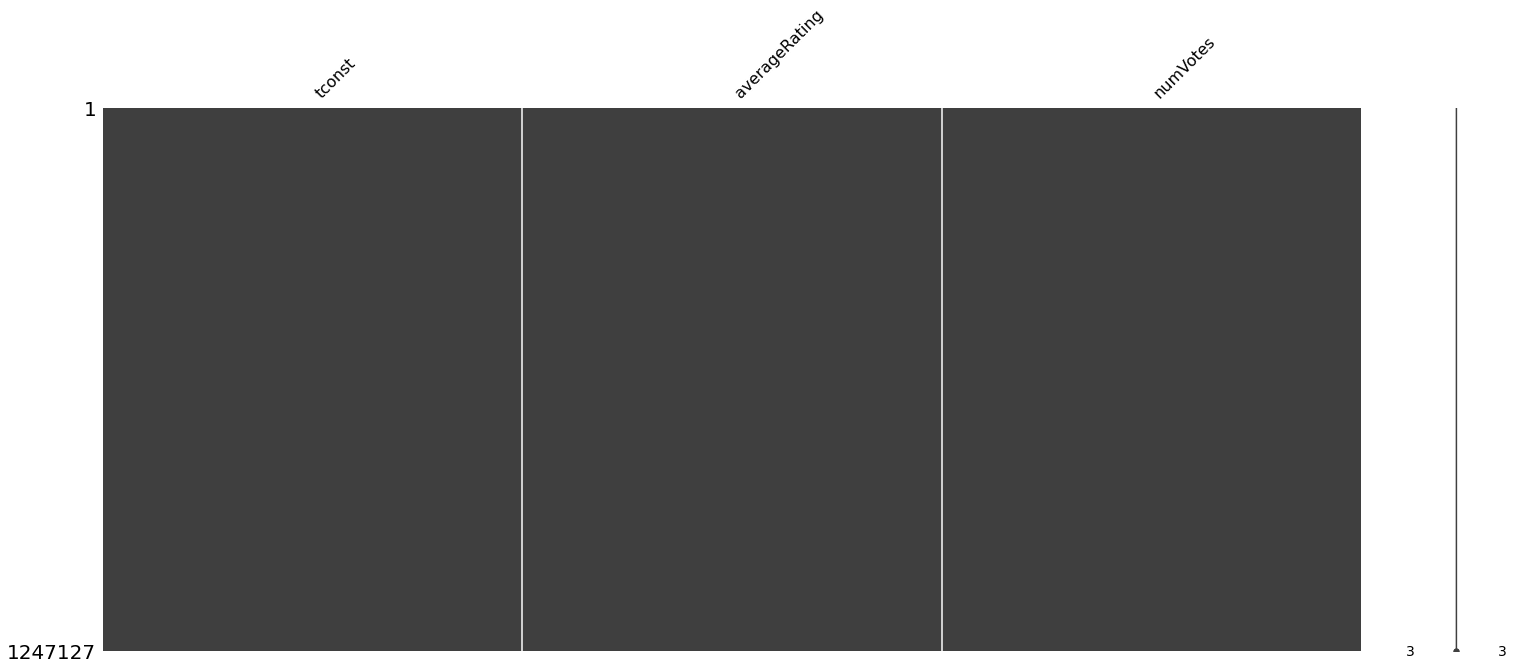

In [17]:
# Replace "\N" with np.nan (if any)
ratings.replace({'\\N':np.nan},inplace=True)
pf.check_nulls_nunique(ratings)

## Processing Title AKAs

#### Specified Filtering Steps:
- keep only US entries.
- Replace "\N" with np.nan

In [19]:
## title AKAs
url_title_akas ="https://datasets.imdbws.com/title.akas.tsv.gz"
akas = pd.read_csv(url_title_akas,sep='\t',low_memory=False)
akas.info()
akas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32090279 entries, 0 to 32090278
Data columns (total 8 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   titleId          object
 1   ordering         int64 
 2   title            object
 3   region           object
 4   language         object
 5   types            object
 6   attributes       object
 7   isOriginalTitle  object
dtypes: int64(1), object(7)
memory usage: 1.9+ GB


,titleId,ordering,title,region,language,types,attributes,isOriginalTitle
0,tt0000001,1,Карменсіта,UA,\N,imdbDisplay,\N,0
1,tt0000001,2,Carmencita,DE,\N,\N,literal title,0
2,tt0000001,3,Carmencita - spanyol tánc,HU,\N,imdbDisplay,\N,0
3,tt0000001,4,Καρμενσίτα,GR,\N,imdbDisplay,\N,0
4,tt0000001,5,Карменсита,RU,\N,imdbDisplay,\N,0


In [20]:
## The AKAs file has the information on country where it released and language
akas = akas[(akas['region'] == 'US')]
akas

,titleId,ordering,title,region,language,types,attributes,isOriginalTitle
5,tt0000001,6,Carmencita,US,\N,imdbDisplay,\N,0
14,tt0000002,7,The Clown and His Dogs,US,\N,\N,literal English title,0
33,tt0000005,10,Blacksmith Scene,US,\N,imdbDisplay,\N,0
36,tt0000005,1,Blacksmithing Scene,US,\N,alternative,\N,0
41,tt0000005,6,Blacksmith Scene #1,US,\N,alternative,\N,0
...,...,...,...,...,...,...,...,...
32089950,tt9916702,1,Loving London: The Playground,US,\N,imdbDisplay,\N,0
32089988,tt9916720,10,The Demonic Nun,US,\N,tv,\N,0
32089990,tt9916720,12,The Nun 2,US,\N,imdbDisplay,\N,0
32090007,tt9916756,1,Pretty Pretty Black Girl,US,\N,imdbDisplay,\N,0


In [21]:
# ## check for null values
# akas.isna().sum()

,# null,% null,# unique,% unique
titleId,0,0.00,1245447,94.11
ordering,0,0.00,109,0.01
title,0,0.00,1022318,77.25
region,0,0.00,1,0.00
language,1319876,99.73,8,0.00
types,297821,22.50,13,0.00
attributes,1279374,96.67,163,0.01
isOriginalTitle,1375,0.10,2,0.00


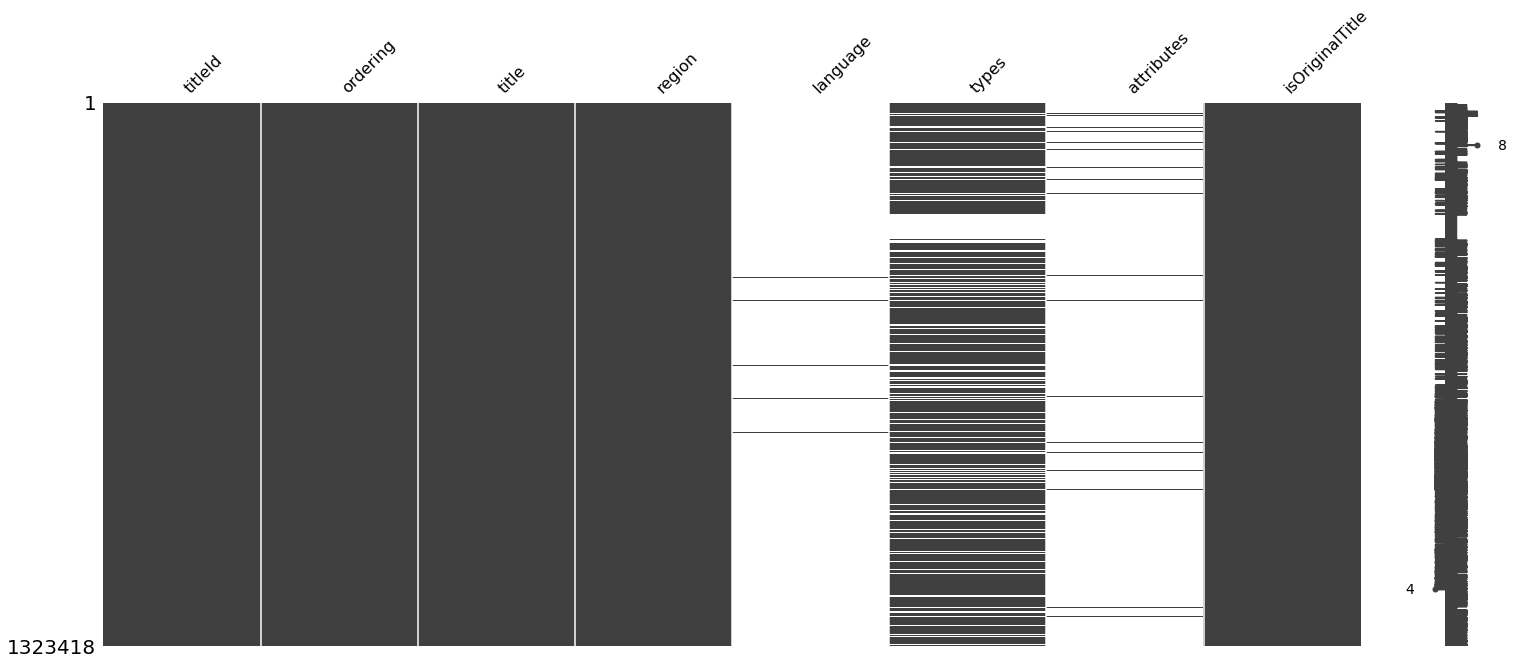

In [22]:
## replace\N placeholders with NaN and re-check for nuls
akas.replace({'\\N':np.nan},inplace=True)
pf.check_nulls_nunique(akas)

#### Observations:
- `language`: workthless, drop it.
- `types`: explore

In [23]:
akas.drop(columns='language',inplace=True)
akas.head()

,titleId,ordering,title,region,types,attributes,isOriginalTitle
5,tt0000001,6,Carmencita,US,imdbDisplay,NaN,0
14,tt0000002,7,The Clown and His Dogs,US,NaN,literal English title,0
33,tt0000005,10,Blacksmith Scene,US,imdbDisplay,NaN,0
36,tt0000005,1,Blacksmithing Scene,US,alternative,NaN,0
41,tt0000005,6,Blacksmith Scene #1,US,alternative,NaN,0


#### Exploring Types

<AxesSubplot:>

/opt/homebrew/Caskroom/miniforge/base/envs/dojo-env-m1/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


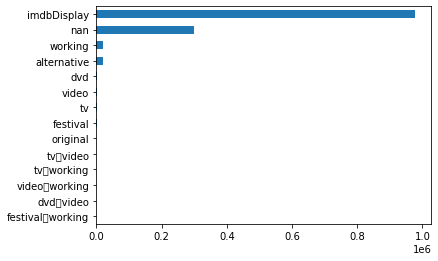

In [24]:
akas['types'].value_counts(dropna=False).sort_values().plot(kind='barh')

> Keep all types, since this table will mainly be used for filtering region and perhaps referenced later for comparing duplicate titles that had unique ids in title basics.

## Final Filtering: Removing Non-US Movies

- Now that both AKAs and basics have been processed, we can remove any movie ids from title basics that are NOT in the US-filtered AKAs dataframe.

### Removing Non-US From Title Basics

In [25]:
## Only keep movie ids that are in the final filtered akas
keepers = basics['tconst'].isin(akas['titleId'])
basics = basics[keepers]
basics

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
34805,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001.0,118,"Comedy,Fantasy,Romance"
61119,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El Tango del Viudo y Su Espejo Deformante,0,2020.0,70,Drama
67672,tt0069049,movie,The Other Side of the Wind,The Other Side of the Wind,0,2018.0,122,Drama
86806,tt0088751,movie,The Naked Monster,The Naked Monster,0,2005.0,100,"Comedy,Horror,Sci-Fi"
91077,tt0093119,movie,Grizzly II: Revenge,Grizzly II: The Predator,0,2020.0,74,"Horror,Music,Thriller"
...,...,...,...,...,...,...,...,...
8947298,tt9915436,movie,Vida em Movimento,Vida em Movimento,0,2019.0,70,Documentary
8947477,tt9915872,movie,The Last White Witch,My Girlfriend is a Wizard,0,2019.0,97,"Comedy,Drama,Fantasy"
8947617,tt9916170,movie,The Rehearsal,O Ensaio,0,2019.0,51,Drama
8947626,tt9916190,movie,Safeguard,Safeguard,0,2020.0,90,"Action,Adventure,Thriller"


### Removing Non-US From Ratings

- I originally used the AKAs table to filter out which movies to keep from ratings.
- I decided to compare using the AKAs table VS the using the basics table, which has already had non-US movies removed.
- Since I will 

In [26]:
## Keeping only movie that exist in basics 
keepers_akas = ratings['tconst'].isin(akas['titleId'])
keepers_basics = ratings['tconst'].isin(basics['tconst'])

print('- If filter using AKAs:')
display(keepers_akas.value_counts())

print('- If filter using Basics:')
display(keepers_basics.value_counts())

- If filter using AKAs:


False    776173
True     470954
Name: tconst, dtype: int64

- If filter using Basics:


False    1162031
True       85096
Name: tconst, dtype: int64

> **MUST DECIDE HOW TO DETERMINE FINAL KEEERS AND IF REMOVING DOCUMENTARIES OR NOT**

In [27]:
ratings_final = ratings[keepers_basics]
ratings_final

,tconst,averageRating,numVotes
17912,tt0035423,6.4,83831
40755,tt0062336,6.4,161
46607,tt0069049,6.7,7236
63597,tt0088751,5.2,320
67378,tt0093119,2.9,1186
...,...,...,...
1247059,tt9915436,7.4,5
1247080,tt9915872,6.9,8
1247093,tt9916170,6.7,6
1247094,tt9916190,3.6,233


## Saving Final Files

#### Saving Title Basics

In [28]:
## Saving and immediately loading (to verify)
basics.to_csv('Data/title_basics_cleaned.csv.gz',compression='gzip',index=False)
basics = pd.read_csv('Data/title_basics_cleaned.csv.gz')
basics.info()
basics.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112958 entries, 0 to 112957
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          112958 non-null  object 
 1   titleType       112958 non-null  object 
 2   primaryTitle    112958 non-null  object 
 3   originalTitle   112958 non-null  object 
 4   isAdult         112958 non-null  int64  
 5   startYear       112958 non-null  float64
 6   runtimeMinutes  112958 non-null  int64  
 7   genres          112958 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.9+ MB


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
0,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001.0,118,"Comedy,Fantasy,Romance"
1,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El Tango del Viudo y Su Espejo Deformante,0,2020.0,70,Drama
2,tt0069049,movie,The Other Side of the Wind,The Other Side of the Wind,0,2018.0,122,Drama
3,tt0088751,movie,The Naked Monster,The Naked Monster,0,2005.0,100,"Comedy,Horror,Sci-Fi"
4,tt0093119,movie,Grizzly II: Revenge,Grizzly II: The Predator,0,2020.0,74,"Horror,Music,Thriller"


#### Saving Title Ratings

In [29]:
ratings_final.to_csv('Data/title_ratings_cleaned.csv.gz',compression='gzip',index=False)
ratings = pd.read_csv('Data/title_ratings_cleaned.csv.gz')
ratings.info()
ratings.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85096 entries, 0 to 85095
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tconst         85096 non-null  object 
 1   averageRating  85096 non-null  float64
 2   numVotes       85096 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ MB


,tconst,averageRating,numVotes
0,tt0035423,6.4,83831
1,tt0062336,6.4,161
2,tt0069049,6.7,7236
3,tt0088751,5.2,320
4,tt0093119,2.9,1186


#### Saving Title AKAs

In [30]:
akas.to_csv('Data/title_akas_cleaned.csv.gz',compression='gzip',index=False)
akas = pd.read_csv('Data/title_akas_cleaned.csv.gz')
akas.info()
akas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323418 entries, 0 to 1323417
Data columns (total 7 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   titleId          1323418 non-null  object 
 1   ordering         1323418 non-null  int64  
 2   title            1323418 non-null  object 
 3   region           1323418 non-null  object 
 4   types            1025597 non-null  object 
 5   attributes       44044 non-null    object 
 6   isOriginalTitle  1322043 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 70.7+ MB


,titleId,ordering,title,region,types,attributes,isOriginalTitle
0,tt0000001,6,Carmencita,US,imdbDisplay,NaN,0.0
1,tt0000002,7,The Clown and His Dogs,US,NaN,literal English title,0.0
2,tt0000005,10,Blacksmith Scene,US,imdbDisplay,NaN,0.0
3,tt0000005,1,Blacksmithing Scene,US,alternative,NaN,0.0
4,tt0000005,6,Blacksmith Scene #1,US,alternative,NaN,0.0


## New Files

### Processing Title Crew

In [31]:
crew = pd.read_csv("https://datasets.imdbws.com/title.crew.tsv.gz",sep='\t',
                   low_memory=False)
crew

,tconst,directors,writers
0,tt0000001,nm0005690,\N
1,tt0000002,nm0721526,\N
2,tt0000003,nm0721526,\N
3,tt0000004,nm0721526,\N
4,tt0000005,nm0005690,\N
...,...,...,...
8947940,tt9916848,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947941,tt9916850,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947942,tt9916852,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947943,tt9916856,nm10538645,nm6951431


In [32]:
## remove placeholders
crew = crew.replace('\\N', np.nan)
crew

,tconst,directors,writers
0,tt0000001,nm0005690,NaN
1,tt0000002,nm0721526,NaN
2,tt0000003,nm0721526,NaN
3,tt0000004,nm0721526,NaN
4,tt0000005,nm0005690,NaN
...,...,...,...
8947940,tt9916848,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947941,tt9916850,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947942,tt9916852,"nm5519454,nm5519375","nm6182221,nm1628284,nm2921377"
8947943,tt9916856,nm10538645,nm6951431


In [33]:
## Keep only moives that are in filtered title basics
crew = crew[crew['tconst'].isin(basics['tconst'])]
crew

,tconst,directors,writers
34805,tt0035423,nm0003506,"nm0737216,nm0003506"
61119,tt0062336,"nm0749914,nm0765384","nm0749914,nm1146177"
67672,tt0069049,nm0000080,"nm0000080,nm0462648"
86806,tt0088751,"nm0628399,nm0078540",nm0628399
91077,tt0093119,nm0007013,"nm0564651,nm0791007"
...,...,...,...
8947298,tt9915436,nm6119329,"nm6449800,nm10537887,nm3644375,nm6119329"
8947477,tt9915872,nm8063415,nm2507310
8947617,tt9916170,nm5412267,"nm5412267,nm6743460,nm3245789"
8947626,tt9916190,nm7308376,nm7308376


In [34]:
## Saving  to disk
crew.to_csv('Data/title_crew_cleaned.csv.gz',compression='gzip',index=False)
crew = pd.read_csv('Data/title_crew_cleaned.csv.gz')
crew

,tconst,directors,writers
0,tt0035423,nm0003506,"nm0737216,nm0003506"
1,tt0062336,"nm0749914,nm0765384","nm0749914,nm1146177"
2,tt0069049,nm0000080,"nm0000080,nm0462648"
3,tt0088751,"nm0628399,nm0078540",nm0628399
4,tt0093119,nm0007013,"nm0564651,nm0791007"
...,...,...,...
112953,tt9915436,nm6119329,"nm6449800,nm10537887,nm3644375,nm6119329"
112954,tt9915872,nm8063415,nm2507310
112955,tt9916170,nm5412267,"nm5412267,nm6743460,nm3245789"
112956,tt9916190,nm7308376,nm7308376


### Processing Name Basics

In [37]:
names =pd.read_csv('https://datasets.imdbws.com/name.basics.tsv.gz',sep='\t')
names

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"soundtrack,actor,miscellaneous","tt0072308,tt0031983,tt0050419,tt0053137"
1,nm0000002,Lauren Bacall,1924,2014,"actress,soundtrack","tt0071877,tt0038355,tt0037382,tt0117057"
2,nm0000003,Brigitte Bardot,1934,\N,"actress,soundtrack,music_department","tt0049189,tt0057345,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,soundtrack,writer","tt0078723,tt0080455,tt0072562,tt0077975"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0083922,tt0050976,tt0050986,tt0060827"
...,...,...,...,...,...,...
11657628,nm9993714,Romeo del Rosario,\N,\N,"animation_department,art_department","tt11657662,tt14069590,tt2455546"
11657629,nm9993716,Essias Loberg,\N,\N,NaN,\N
11657630,nm9993717,Harikrishnan Rajan,\N,\N,cinematographer,tt8736744
11657631,nm9993718,Aayush Nair,\N,\N,cinematographer,\N


> Only save nconsts that have tconst's included in basics

In [38]:
names['tconsts'] = names['knownForTitles'].str.split(',')
names_explode = names.explode('tconsts')
names_explode

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles,tconsts
0,nm0000001,Fred Astaire,1899,1987,"soundtrack,actor,miscellaneous","tt0072308,tt0031983,tt0050419,tt0053137",tt0072308
0,nm0000001,Fred Astaire,1899,1987,"soundtrack,actor,miscellaneous","tt0072308,tt0031983,tt0050419,tt0053137",tt0031983
0,nm0000001,Fred Astaire,1899,1987,"soundtrack,actor,miscellaneous","tt0072308,tt0031983,tt0050419,tt0053137",tt0050419
0,nm0000001,Fred Astaire,1899,1987,"soundtrack,actor,miscellaneous","tt0072308,tt0031983,tt0050419,tt0053137",tt0053137
1,nm0000002,Lauren Bacall,1924,2014,"actress,soundtrack","tt0071877,tt0038355,tt0037382,tt0117057",tt0071877
...,...,...,...,...,...,...,...
11657628,nm9993714,Romeo del Rosario,\N,\N,"animation_department,art_department","tt11657662,tt14069590,tt2455546",tt2455546
11657629,nm9993716,Essias Loberg,\N,\N,NaN,\N,\N
11657630,nm9993717,Harikrishnan Rajan,\N,\N,cinematographer,tt8736744,tt8736744
11657631,nm9993718,Aayush Nair,\N,\N,cinematographer,\N,\N


In [39]:
## filter exploded using basics tconsts -
keepers = names_explode[names_explode['tconsts'].isin(basics['tconst'])]
keepers


,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles,tconsts
15,nm0000016,Georges Delerue,1925,1992,"composer,soundtrack,music_department","tt0091763,tt8847712,tt0096320,tt0069946",tt8847712
34,nm0000035,James Horner,1953,2015,"music_department,soundtrack,composer","tt0120746,tt0120338,tt0499549,tt0090633",tt0499549
48,nm0000049,Henry Mancini,1924,1994,"music_department,soundtrack,composer","tt0085101,tt0054698,tt0383216,tt0057413",tt0383216
54,nm0000055,Alfred Newman,1900,1970,"music_department,composer,soundtrack","tt0049408,tt0434409,tt0065377,tt0042192",tt0434409
55,nm0000056,Paul Newman,1925,2008,"actor,producer,director","tt0061512,tt0084855,tt0257044,tt0054997",tt0257044
...,...,...,...,...,...,...,...
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502",tt11580944
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502",tt12856788
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502",tt8302382
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502",tt13847502


In [40]:
## save nconst
keep_nconsts = keepers['nconst'].unique()
keep_nconsts

array(['nm0000016', 'nm0000035', 'nm0000049', ..., 'nm9993685',
       'nm9993693', 'nm9993714'], dtype=object)

In [43]:
## use filtered nconsts to filter original names df
names_clean = names[names['nconst'].isin(keep_nconsts)]
names_clean

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles,tconsts
15,nm0000016,Georges Delerue,1925,1992,"composer,soundtrack,music_department","tt0091763,tt8847712,tt0096320,tt0069946","[tt0091763, tt8847712, tt0096320, tt0069946]"
34,nm0000035,James Horner,1953,2015,"music_department,soundtrack,composer","tt0120746,tt0120338,tt0499549,tt0090633","[tt0120746, tt0120338, tt0499549, tt0090633]"
48,nm0000049,Henry Mancini,1924,1994,"music_department,soundtrack,composer","tt0085101,tt0054698,tt0383216,tt0057413","[tt0085101, tt0054698, tt0383216, tt0057413]"
54,nm0000055,Alfred Newman,1900,1970,"music_department,composer,soundtrack","tt0049408,tt0434409,tt0065377,tt0042192","[tt0049408, tt0434409, tt0065377, tt0042192]"
55,nm0000056,Paul Newman,1925,2008,"actor,producer,director","tt0061512,tt0084855,tt0257044,tt0054997","[tt0061512, tt0084855, tt0257044, tt0054997]"
...,...,...,...,...,...,...,...
11657573,nm9993653,Marek Jastrzebski,\N,\N,"producer,actor","tt8308330,tt8649186,tt8739208","[tt8308330, tt8649186, tt8739208]"
11657599,nm9993684,Angela Ng,\N,\N,miscellaneous,"tt3741700,tt10182516","[tt3741700, tt10182516]"
11657600,nm9993685,John Root,\N,\N,miscellaneous,tt3741700,[tt3741700]
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502","[tt11580944, tt12856788, tt8302382, tt13847502]"


In [44]:
# drop tconsts
names_clean = names_clean.drop(columns=['tconsts'])
names_clean

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
15,nm0000016,Georges Delerue,1925,1992,"composer,soundtrack,music_department","tt0091763,tt8847712,tt0096320,tt0069946"
34,nm0000035,James Horner,1953,2015,"music_department,soundtrack,composer","tt0120746,tt0120338,tt0499549,tt0090633"
48,nm0000049,Henry Mancini,1924,1994,"music_department,soundtrack,composer","tt0085101,tt0054698,tt0383216,tt0057413"
54,nm0000055,Alfred Newman,1900,1970,"music_department,composer,soundtrack","tt0049408,tt0434409,tt0065377,tt0042192"
55,nm0000056,Paul Newman,1925,2008,"actor,producer,director","tt0061512,tt0084855,tt0257044,tt0054997"
...,...,...,...,...,...,...
11657573,nm9993653,Marek Jastrzebski,\N,\N,"producer,actor","tt8308330,tt8649186,tt8739208"
11657599,nm9993684,Angela Ng,\N,\N,miscellaneous,"tt3741700,tt10182516"
11657600,nm9993685,John Root,\N,\N,miscellaneous,tt3741700
11657608,nm9993693,Apsara Rani,\N,\N,actress,"tt11580944,tt12856788,tt8302382,tt13847502"


In [46]:
names_clean = names_clean.replace('\\N', np.nan)
names_clean

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
15,nm0000016,Georges Delerue,1925,1992,"composer,soundtrack,music_department","tt0091763,tt8847712,tt0096320,tt0069946"
34,nm0000035,James Horner,1953,2015,"music_department,soundtrack,composer","tt0120746,tt0120338,tt0499549,tt0090633"
48,nm0000049,Henry Mancini,1924,1994,"music_department,soundtrack,composer","tt0085101,tt0054698,tt0383216,tt0057413"
54,nm0000055,Alfred Newman,1900,1970,"music_department,composer,soundtrack","tt0049408,tt0434409,tt0065377,tt0042192"
55,nm0000056,Paul Newman,1925,2008,"actor,producer,director","tt0061512,tt0084855,tt0257044,tt0054997"
...,...,...,...,...,...,...
11657573,nm9993653,Marek Jastrzebski,NaN,NaN,"producer,actor","tt8308330,tt8649186,tt8739208"
11657599,nm9993684,Angela Ng,NaN,NaN,miscellaneous,"tt3741700,tt10182516"
11657600,nm9993685,John Root,NaN,NaN,miscellaneous,tt3741700
11657608,nm9993693,Apsara Rani,NaN,NaN,actress,"tt11580944,tt12856788,tt8302382,tt13847502"


In [47]:
names_clean.to_csv('Data/names_basics.csv.gz',compression='gzip', index=False)
names = pd.read_csv('Data/names_basics.csv.gz')
names

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000016,Georges Delerue,1925.0,1992.0,"composer,soundtrack,music_department","tt0091763,tt8847712,tt0096320,tt0069946"
1,nm0000035,James Horner,1953.0,2015.0,"music_department,soundtrack,composer","tt0120746,tt0120338,tt0499549,tt0090633"
2,nm0000049,Henry Mancini,1924.0,1994.0,"music_department,soundtrack,composer","tt0085101,tt0054698,tt0383216,tt0057413"
3,nm0000055,Alfred Newman,1900.0,1970.0,"music_department,composer,soundtrack","tt0049408,tt0434409,tt0065377,tt0042192"
4,nm0000056,Paul Newman,1925.0,2008.0,"actor,producer,director","tt0061512,tt0084855,tt0257044,tt0054997"
...,...,...,...,...,...,...
2426761,nm9993653,Marek Jastrzebski,NaN,NaN,"producer,actor","tt8308330,tt8649186,tt8739208"
2426762,nm9993684,Angela Ng,NaN,NaN,miscellaneous,"tt3741700,tt10182516"
2426763,nm9993685,John Root,NaN,NaN,miscellaneous,tt3741700
2426764,nm9993693,Apsara Rani,NaN,NaN,actress,"tt11580944,tt12856788,tt8302382,tt13847502"


### Processing Title Principals

In [48]:
principals = pd.read_csv('https://datasets.imdbws.com/title.principals.tsv.gz',
                        sep='\t')
principals

,tconst,ordering,nconst,category,job,characters
0,tt0000001,1,nm1588970,self,\N,"[""Self""]"
1,tt0000001,2,nm0005690,director,\N,\N
2,tt0000001,3,nm0374658,cinematographer,director of photography,\N
3,tt0000002,1,nm0721526,director,\N,\N
4,tt0000002,2,nm1335271,composer,\N,\N
...,...,...,...,...,...,...
50453286,tt9916880,4,nm10535738,actress,\N,"[""Horrid Henry""]"
50453287,tt9916880,5,nm0996406,director,principal director,\N
50453288,tt9916880,6,nm1482639,writer,\N,\N
50453289,tt9916880,7,nm2586970,writer,books,\N


In [49]:
## filter based on final basics
principals = principals[principals['tconst'].isin(basics['tconst'])]
principals

,tconst,ordering,nconst,category,job,characters
282482,tt0035423,10,nm0107463,editor,\N,\N
282483,tt0035423,1,nm0000212,actress,\N,"[""Kate McKay""]"
282484,tt0035423,2,nm0413168,actor,\N,"[""Leopold""]"
282485,tt0035423,3,nm0000630,actor,\N,"[""Stuart Besser""]"
282486,tt0035423,4,nm0005227,actor,\N,"[""Charlie McKay""]"
...,...,...,...,...,...,...
50452004,tt9916362,5,nm1893148,director,\N,\N
50452005,tt9916362,6,nm3471432,writer,screenplay by,\N
50452006,tt9916362,7,nm2970042,producer,executive producer,\N
50452007,tt9916362,8,nm4065853,producer,producer,\N


In [50]:
principals = principals.replace('\\N',np.nan)
principals

,tconst,ordering,nconst,category,job,characters
282482,tt0035423,10,nm0107463,editor,NaN,NaN
282483,tt0035423,1,nm0000212,actress,NaN,"[""Kate McKay""]"
282484,tt0035423,2,nm0413168,actor,NaN,"[""Leopold""]"
282485,tt0035423,3,nm0000630,actor,NaN,"[""Stuart Besser""]"
282486,tt0035423,4,nm0005227,actor,NaN,"[""Charlie McKay""]"
...,...,...,...,...,...,...
50452004,tt9916362,5,nm1893148,director,NaN,NaN
50452005,tt9916362,6,nm3471432,writer,screenplay by,NaN
50452006,tt9916362,7,nm2970042,producer,executive producer,NaN
50452007,tt9916362,8,nm4065853,producer,producer,NaN


In [51]:
principals.to_csv('Data/title_principals.csv.gz',compression='gzip', index=False)
principals = pd.read_csv('Data/title_principals.csv.gz')
principals

,tconst,ordering,nconst,category,job,characters
0,tt0035423,10,nm0107463,editor,NaN,NaN
1,tt0035423,1,nm0000212,actress,NaN,"[""Kate McKay""]"
2,tt0035423,2,nm0413168,actor,NaN,"[""Leopold""]"
3,tt0035423,3,nm0000630,actor,NaN,"[""Stuart Besser""]"
4,tt0035423,4,nm0005227,actor,NaN,"[""Charlie McKay""]"
...,...,...,...,...,...,...
920993,tt9916362,5,nm1893148,director,NaN,NaN
920994,tt9916362,6,nm3471432,writer,screenplay by,NaN
920995,tt9916362,7,nm2970042,producer,executive producer,NaN
920996,tt9916362,8,nm4065853,producer,producer,NaN


### Optional Check for files in Data folder

In [52]:
# optional 
sorted(os.listdir("Data/"))

['combined_tmdb_api_data.csv.gz',
 'final_tmdb_data_2000.csv.gz',
 'final_tmdb_data_2001.csv.gz',
 'final_tmdb_data_2002.csv.gz',
 'final_tmdb_data_2003.csv.gz',
 'final_tmdb_data_2004.csv.gz',
 'final_tmdb_data_2005.csv.gz',
 'final_tmdb_data_2006.csv.gz',
 'final_tmdb_data_2007.csv.gz',
 'final_tmdb_data_2008.csv.gz',
 'final_tmdb_data_2009.csv.gz',
 'final_tmdb_data_2010.csv.gz',
 'final_tmdb_data_2011.csv.gz',
 'final_tmdb_data_2012.csv.gz',
 'final_tmdb_data_2013.csv.gz',
 'final_tmdb_data_2014.csv.gz',
 'final_tmdb_data_2015.csv.gz',
 'final_tmdb_data_2016.csv.gz',
 'final_tmdb_data_2017.csv.gz',
 'final_tmdb_data_2018.csv.gz',
 'final_tmdb_data_2019.csv.gz',
 'final_tmdb_data_2020.csv.gz',
 'final_tmdb_data_2021.csv.gz',
 'final_tmdb_data_2022.csv.gz',
 'names_basics.csv.gz',
 'title_akas_cleaned.csv.gz',
 'title_basics_cleaned.csv.gz',
 'title_crew_cleaned.csv.gz',
 'title_principals.csv.gz',
 'title_ratings_cleaned.csv.gz',
 'tmdb_api_results_2000.json']

## Final Movie Count

In [53]:
print(f"There are {len(basics):,} rows in title_basics")
print(f"There are {len(ratings):,} rows in title_ratings")
print(f"There are {len(akas):,} rows in akas")
print(f"There are {len(names):,} rows in names basics")
print(f"There are {len(crew):,} rows in title crew")

There are 112,958 rows in title_basics
There are 85,096 rows in title_ratings
There are 1,323,418 rows in akas
There are 2,426,766 rows in names basics
There are 112,958 rows in title crew


> See notebook "`Part 2A - TMDB API Calls.ipynb`" for the next part of the analysis.